In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
work_df = pd.read_csv('data/work_df.csv')
work_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3115 entries, 0 to 3114
Data columns (total 52 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   study_ID      3115 non-null   object 
 1   gender        3115 non-null   int64  
 2   age           3115 non-null   int64  
 3   rbc           1498 non-null   float64
 4   hgb           1506 non-null   float64
 5   hct           1530 non-null   float64
 6   mcv           1549 non-null   float64
 7   mch           1551 non-null   float64
 8   mchc          1558 non-null   float64
 9   rdw           805 non-null    float64
 10  rdv_cv        683 non-null    float64
 11  rdv_sd        686 non-null    float64
 12  ret_rel       52 non-null     float64
 13  ret_abs       40 non-null     float64
 14  cp            802 non-null    float64
 15  anisocytos    970 non-null    float64
 16  hypochromia   245 non-null    float64
 17  macrocytos    141 non-null    float64
 18  microcytos    168 non-null  

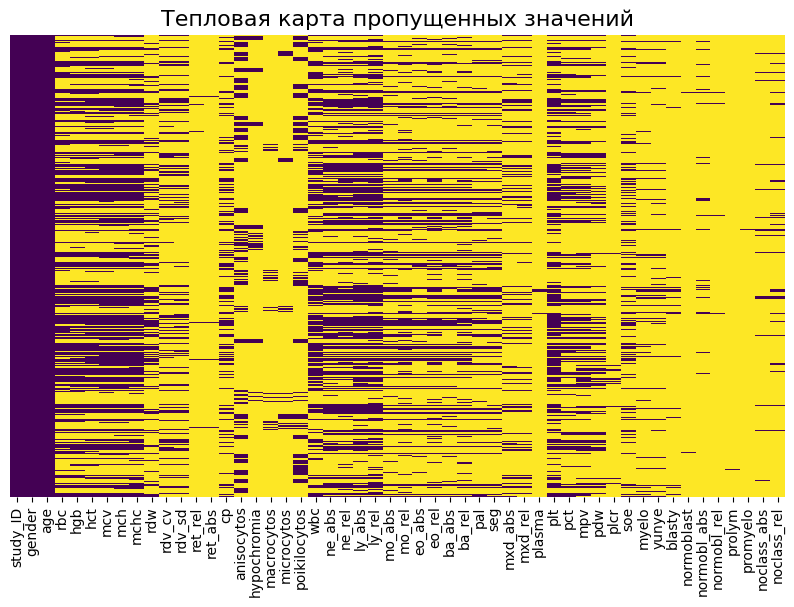

In [3]:
# Создаем тепловую карту пропусков
plt.figure(figsize=(10, 6))
sns.heatmap(work_df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Тепловая карта пропущенных значений', fontsize=16)
plt.show()

In [4]:
def rel_tocol_calc(rel_col, abs_col):
    # Условия: есть rel, есть WBC, нет abs
    cond_rel_to_abs = (
        work_df[rel_col].notna() &
        work_df['wbc'].notna() &
        work_df[abs_col].isna()
    )

    work_df.loc[cond_rel_to_abs, abs_col] = (
        work_df.loc[cond_rel_to_abs, rel_col] * work_df.loc[cond_rel_to_abs, 'wbc'] * 0.01
    )

    cond_rel_to_wbc = (
        work_df[rel_col].notna() &
        work_df['wbc'].isna() &
        work_df[abs_col].notna()    
    )

    work_df.loc[cond_rel_to_wbc, 'wbc'] = (
        work_df.loc[cond_rel_to_wbc, abs_col] / work_df.loc[cond_rel_to_wbc, rel_col] * 100
    )

In [5]:
# Пары: (абсолютное, относительное)
leukocyte_pairs = [
    ('ne_abs', 'ne_rel'),
    ('ly_abs', 'ly_rel'),
    ('mo_abs', 'mo_rel'),
    ('eo_abs', 'eo_rel'),
    ('ba_abs', 'ba_rel'),
    ('mxd_abs', 'mxd_rel'),
    ('ret_abs', 'ret_rel'),
    ('noclass_abs', 'noclass_rel'),
]

# Перебор всех пар
for abs_col, rel_col in leukocyte_pairs:
    rel_tocol_calc(abs_col, rel_col)


HCT (%) = RBC (кол-во эритроцитов, ×10¹²/л) × MCV (средний объем эритроцита, фл) × 0.1

In [6]:
# Расчитаем значения по эритроцитам через Hct и MCV
cond_hct = (
    work_df['hct'].isna() &
    work_df['rbc'].notna() &
    work_df['mcv'].notna()
)

work_df.loc[cond_hct, 'hct'] = (
    work_df.loc[cond_hct, 'rbc'] * work_df.loc[cond_hct, 'mcv'] * 0.1
)

cond_rbc = (
    work_df['hct'].notna() &
    work_df['rbc'].isna() &
    work_df['mcv'].notna()
)

work_df.loc[cond_rbc, 'rbc'] = (
    work_df.loc[cond_rbc, 'hct'] * 10 / work_df.loc[cond_rbc, 'mcv']
)

cond_mcv = (
    work_df['hct'].notna() &
    work_df['rbc'].notna() &
    work_df['mcv'].isna()
)

work_df.loc[cond_mcv, 'mcv'] = (
    work_df.loc[cond_mcv, 'hct'] * 10 / work_df.loc[cond_mcv, 'rbc']
)

In [7]:
# Расчитаем значения по эритроцитам через hgb и MCH
cond_hgb = (
    work_df['hgb'].isna() &
    work_df['rbc'].notna() &
    work_df['mch'].notna()
)

work_df.loc[cond_hgb, 'hgb'] = (
    work_df.loc[cond_hgb, 'rbc'] * work_df.loc[cond_hgb, 'mch'] * 0.1
)

cond_rbc = (
    work_df['hgb'].notna() &
    work_df['rbc'].isna() &
    work_df['mch'].notna()
)

work_df.loc[cond_rbc, 'rbc'] = (
    work_df.loc[cond_rbc, 'hgb'] * 10 / work_df.loc[cond_rbc, 'mch']
)

cond_mch = (
    work_df['hgb'].notna() &
    work_df['rbc'].notna() &
    work_df['mch'].isna()
)

work_df.loc[cond_mch, 'mch'] = (
    work_df.loc[cond_mch, 'hgb'] * 10 / work_df.loc[cond_mch, 'rbc']
)

In [8]:
# Расчитаем значения по тромбоцитам где можно
cond_pct = (
    work_df['pct'].isna() &
    work_df['plt'].notna() &
    work_df['mpv'].notna()
)

work_df.loc[cond_pct, 'pct'] = (
    work_df.loc[cond_pct, 'plt'] * work_df.loc[cond_pct, 'mpv'] * 0.1
)

cond_plt = (
    work_df['pct'].notna() &
    work_df['plt'].isna() &
    work_df['mpv'].notna()
)

work_df.loc[cond_plt, 'plt'] = (
    work_df.loc[cond_plt, 'pct'] * 10 / work_df.loc[cond_plt, 'mpv']
)

cond_mpv = (
    work_df['pct'].notna() &
    work_df['plt'].notna() &
    work_df['mpv'].isna()
)

work_df.loc[cond_mpv, 'mpv'] = (
    work_df.loc[cond_mpv, 'pct'] * 10 / work_df.loc[cond_mpv, 'plt']
)

In [9]:
list_to_drop = [
    'ne_rel', 'ly_rel', 'mo_rel', 'ret_rel',
    'eo_rel', 'ba_rel', 'mxd_rel', 'normobl_rel',
    'pct', 'mch', 'rdv_cv',
    'noclass_abs', 'noclass_rel',

]
work_df = work_df.drop(columns=list_to_drop)

In [10]:
norm_null_list = ['plasma', 'myelo', 'yunye', 'blasty', 'normobl_abs',
                  'prolym', 'promyelo', 'normoblast',
                  'plcr', 'hypochromia',
                  'macrocytos', 'microcytos',
                  'anisocytos', 'poikilocytos',
                  ]
# Заменим пустые значения но 0 (норма там где можно)
work_df[norm_null_list] = work_df[norm_null_list].fillna(0)

In [11]:
work_df = work_df.dropna(subset=['rbc', 'wbc'], how='all')
work_df.shape

(1924, 39)

In [12]:
leu_formula_list = ['ne_abs', 'ly_abs', 'mo_abs',
                    'eo_abs', 'ba_abs', 
                    'pal', 'seg', 'mxd_abs', 'plasma', # в норме - 0-1%
                    ]

leuf_df = work_df[leu_formula_list]

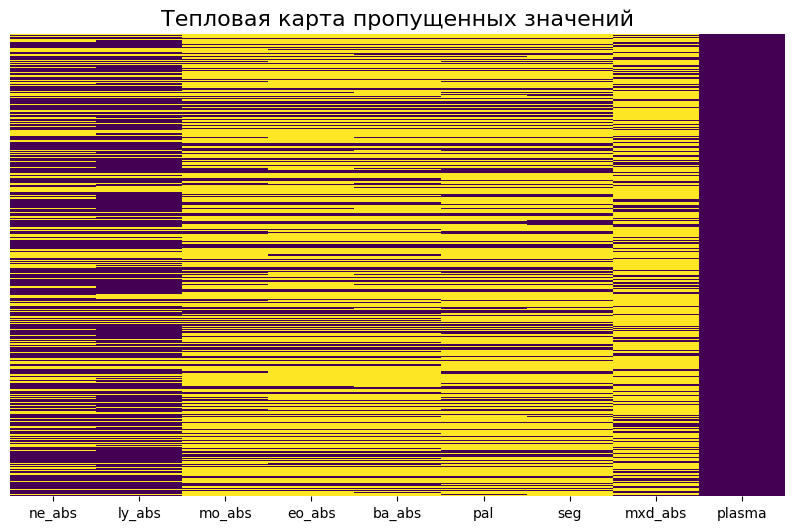

In [13]:
# Создаем тепловую карту пропусков
plt.figure(figsize=(10, 6))
sns.heatmap(leuf_df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Тепловая карта пропущенных значений', fontsize=16)
plt.show()

In [15]:
cat_list = ['study_ID', 'gender', 'plasma', 'myelo', 'yunye', 'blasty',
            'prolym', 'promyelo', 'normoblast', 'hypochromia',
            'macrocytos', 'microcytos', 'anisocytos', 'poikilocytos',]
num_list = [col for col in work_df.columns if col not in cat_list]
work_df[cat_list] = work_df[cat_list].astype('object')

In [16]:
ref_dict = { # Словарь референсных значений
    'rbc': [3.8, 5.8],
    'hgb': [120, 140],
    'hct': [39, 49],
    'mcv': [81, 100],
    'mchc': [320, 360],
    'rdw': [11.5, 14.5],
    'rdv_sd': [37, 54],
    'ret_abs': [0.67, 1.9],
    'cp': [0.85, 1],
    'wbc': [4, 9],
    'ne_abs': [2, 5.5],
    'ly_abs': [1, 4.8],
    'mo_abs': [0.04, 0.7],
    'eo_abs': [0.02, 0.45],
    'ba_abs': [0.01, 0.05],
    'pal': [1, 5],
    'seg': [47, 72],
    'mxd_abs': [0.2, 0.8],
    'plt': [180, 320],
    'mpv': [7.4, 10.4],
    'pdw': [15, 17],
    'plcr': [13, 43],
    'soe': [2, 10],
    'ret_abs': [17, 63],
}

In [17]:
import numpy as np
np.random.seed(42)

for col in ref_dict:
    mask = work_df[col].isna()
    work_df.loc[mask, col] = np.random.uniform(ref_dict[col][0], ref_dict[col][1], size=mask.sum())

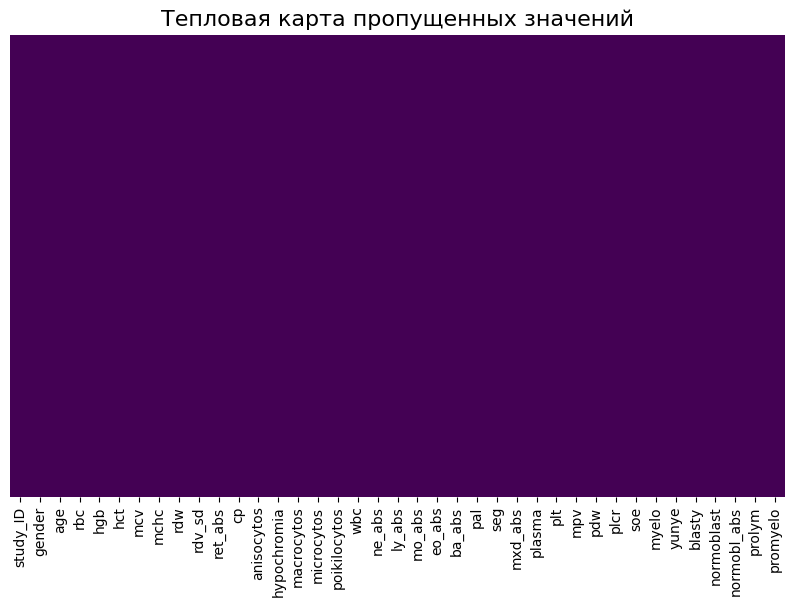

In [21]:
# Создаем тепловую карту пропусков
plt.figure(figsize=(10, 6))
sns.heatmap(work_df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Тепловая карта пропущенных значений', fontsize=16)
plt.show()

In [20]:
# work_df[work_df.isnull().sum(axis=1) < 10].describe().T
work_df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1924.0,71.284823,10.661431,10.000000,67.000000,71.000000,77.000000,90.00
rbc,1924.0,3.955733,1.385590,1.100000,3.020000,3.810000,4.741107,10.58
hgb,1924.0,109.388949,32.461667,5.344828,89.000000,112.000000,131.000000,220.00
hct,1924.0,34.655022,10.620728,9.000000,26.200000,33.700000,43.000000,71.70
mcv,1924.0,85.813017,8.905726,59.900000,80.000000,84.480120,90.525000,136.30
mchc,1924.0,325.419657,62.922962,24.400000,324.000000,338.000000,350.000000,404.00
rdw,1924.0,14.546764,2.866564,10.000000,12.655785,13.717941,15.300000,34.90
rdv_sd,1924.0,47.508011,7.079592,34.000000,42.209749,47.146982,51.304203,97.60
ret_abs,1924.0,40.508569,15.442723,6.800000,28.413682,39.662452,51.713159,186.60
cp,1924.0,0.900274,0.084162,0.490000,0.861867,0.900769,0.949577,1.35


In [19]:
work_df.describe(include='object').T

,count,unique,top,freq
study_ID,1924,1924,05deb1af-cf40-11e9-80ba-901b0e633689_result_1802,1
gender,1924,2,0,1048
anisocytos,1924.0,2.0,0.0,1785.0
hypochromia,1924.0,2.0,0.0,1895.0
macrocytos,1924.0,2.0,0.0,1913.0
microcytos,1924.0,2.0,0.0,1908.0
poikilocytos,1924.0,2.0,0.0,1830.0
plasma,1924.0,10.0,0.0,1904.0
myelo,1924.0,28.0,0.0,1683.0
yunye,1924.0,25.0,0.0,1708.0


In [22]:
etalon_df = work_df.copy()

In [ ]:
# etalon_df.to_csv('data/etalon_df.csv')